# Metric learning - Triplet Loss

- Trenira se mreža gde se svaka slika preslikava u N-dimenzioni prostor, ali tako da slike koje označavaju isto slovo budu blizu jedna drugoj, a one koje označavaju različita slova budu daleko jedna od druge
- triplet loss - za svaku trojku slika (anchor - polazna slika, positive - drugi primer istog slova, negative - primer drugog slova) loss podstiče da rastojanje anchor-positive bude amnje od rastojanja anchor-negative za bar zadatu marginu

In [4]:
import json
import sys
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from pytorch_metric_learning import losses, miners
from pytorch_metric_learning.samplers import MPerClassSampler

from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances

sys.path.insert(0, str(Path.cwd()))
from data_utils import (
    build_datasets,
    LABEL_TO_LETTER,
    NUM_CLASSES,
    SEED,
)
# Podešavanja izgleda grafika (rezolucija i veličina fonta) za sve grafike u notebook-u
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

# Konstante

In [5]:
RESULTS_DIR = Path("../results/Triplet model")
RESULTS_DIR.mkdir(exist_ok=True)

EMBEDDING_DIM = 128  
MARGIN = 0.2  

M_PER_CLASS = 4  # broj primera po slovu u svakom batch-u 
TRIPLET_BATCH_SIZE = NUM_CLASSES * M_PER_CLASS  # 24 * 4 = 96, tako da je svako slovo zastupljeno u svakom batch-u
EVAL_BATCH_SIZE = 256  # veći batch za računanje embeddinga (bez treniranja, samo forward prolaz kroz mrežu)

EPOCHS = 40
LEARNING_RATE = 1e-3
PATIENCE = 5  

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu") #ukoliko u okruzenju postoji GPU, za brze izvrsavanje
print(f"Uređaj: {DEVICE}")

Uređaj: cpu


## Fiksiranje vrednosti seed
- fiksira se pomoću seed-a random vrednosti, jer bi pri svakom pokretanju vrednosti bile drugačije, što će da oteža i poređenje modela

In [6]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
print(f"Seed fiksiran na {SEED}")

Seed fiksiran na 42


## Učitavanje pripremljenih podataka


In [7]:
train_ds, val_ds, test_ds = build_datasets(with_augmentation=True)

print(f"Train: {len(train_ds)} primera")
print(f"Val:   {len(val_ds)} primera")
print(f"Test:  {len(test_ds)} primera")

Train: 23336 primera
Val:   4119 primera
Test:  7172 primera


## Uzorkovanje batch-eva po klasi (MPerClassSampler)

- svaki batch treba da sadrži više slika za isto slovo, jer se traže trojke, jer u suprotnom nema sa čine da uporedimo i onda je beskorisno za treniranje
- sampler se koristi na trening i validacionom skupu

In [8]:
train_sampler = MPerClassSampler(
    train_ds.labels, m=M_PER_CLASS, batch_size=TRIPLET_BATCH_SIZE, length_before_new_iter=len(train_ds)
)
val_sampler = MPerClassSampler(
    val_ds.labels, m=M_PER_CLASS, batch_size=TRIPLET_BATCH_SIZE, length_before_new_iter=len(val_ds)
)

train_loader = DataLoader(train_ds, batch_size=TRIPLET_BATCH_SIZE, sampler=train_sampler)
val_loader = DataLoader(val_ds, batch_size=TRIPLET_BATCH_SIZE, sampler=val_sampler)

images, labels = next(iter(train_loader))
broj_slova_u_batchu = len(set(labels.tolist()))
print(f"Batch slika: {images.shape}, dtype={images.dtype}")
print(f"Broj različitih slova u batch-u: {broj_slova_u_batchu} (očekivano: {NUM_CLASSES})")
print(f"Primera po slovu u batch-u: {len(labels) / broj_slova_u_batchu:.0f}")

Batch slika: torch.Size([96, 1, 28, 28]), dtype=torch.float32
Broj različitih slova u batch-u: 24 (očekivano: 24)
Primera po slovu u batch-u: 4


## Arhitektura embedding mreže

Mreža ima dva dela: 
- features: iz slike izvlači karakteristike slike
- embedding: na osnovu tih karakteristika generiše kompaktan vektorski prikaz slova
  
**features** je organizovan u tri bloka, svaki sledeći blok ima više filtera (32 -> 64 -> 128). Početni slojevi hvataju jednostavne stvari (ivice, konture prstiju), a dublji slojevi kombinuju to u složenije obrasce (oblik šake, položaj prstiju). Svaki blok ima:
- dva konvolutivna sloja + batch normalizaciju (stabilizuje treniranje) + ReLU aktivacionu funkciju
- MaxPool2d na kraju bloka, koji upola smanjuje dimenzije slike (28 -> 14 -> 7 -> 3)
- Dropout da se mreža ne oslanja previše na pojedinačne neurone (sprečava overfitting)

**embedding** - umesto classifier glave sa NUM_CLASSES izlaza (kao kod CNN-a), ovde imamo Linear sloj koji slika izlaz iz poslednjeg bloka (spljošten pomoću Flatten) u vektor od EMBEDDING_DIM=128 brojeva, nakon čega sledi L2 normalizacija (F.normalize)

In [9]:
class EmbeddingNet(nn.Module):
    def __init__(self, embedding_dim=EMBEDDING_DIM):
        super().__init__()

        # Ista arhitektura kao ya CNN
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),
        )

        self.embedding = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, embedding_dim),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.embedding(x)
        x = F.normalize(x, p=2, dim=1)  # L2 normalizacija - svaki embedding vektor ima jediničnu dužinu
        return x


model = EmbeddingNet().to(DEVICE)

In [10]:
# Provera dimenzija i normi izlaza na jednom batch-u
with torch.no_grad():
    sample_out = model(images.to(DEVICE))
print(f"Oblik embeddinga: {sample_out.shape}")
print(f"Norme embeddinga (prvih 5): {sample_out.norm(dim=1)[:5].cpu().numpy()}") 

Oblik embeddinga: torch.Size([96, 128])
Norme embeddinga (prvih 5): [0.99999994 1.         1.         0.99999994 1.        ]


## Triplet loss i miner

- **TripletMarginLoss(margin=MARGIN)** - za trojku (anchor, positive, negative) računa max(0, d(anchor,positive) - d(anchor,negative) + margin), gde je d euklidsko rastojanje.
-  Loss je 0 kada je negative već dovoljno dalje od positive-a (za bar margin), a pozitivan kada mreža treba još da "razdvoji" tu trojku.
- **TripletMarginMiner(margin=MARGIN, type_of_triplets="semihard")** - Bira samo one koje su trenutno "informativne" za treniranje, umesto da se loss računa nad svim kombinacijama.
- Tip "semihard" bira negative primere koji su dalji od positive-a, ali su i dalje unutar margine 
- Broj trojki na početku treninga je veći, a kako mreža uči tako taj broj opada 

In [11]:
loss_func = losses.TripletMarginLoss(margin=MARGIN)
mining_func = miners.TripletMarginMiner(margin=MARGIN, type_of_triplets="semihard")

## Pomoćna funkcija za jednu epohu treniranja/evaluacije

- ista funkcija se koristi i za trening i za validaciju (kada je prosleđen optimizer radimo trening, inače samo evaluaciju)
- prati se prosečan broj mined trojki po primeru - "koliko je trenutno teško" mreži da razdvoji slova

In [12]:
def run_epoch(model, loader, loss_func, mining_func, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_triplets, total_samples = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            if is_train:
                optimizer.zero_grad()
            embeddings = model(images)
            indices_tuple = mining_func(embeddings, labels)
            loss = loss_func(embeddings, labels, indices_tuple)
            if is_train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            total_triplets += mining_func.num_triplets
            total_samples += images.size(0)
    return total_loss / total_samples, total_triplets / total_samples

## Trening petlja

- optimizator: Adam
- loss funkcija: TripletMarginLoss, TripletMarginMiner
- ReduceLROnPlateau za smanjenje learning rate-a 
- history: rečnik u koji se posle svake epohe upisuju loss 

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=PATIENCE
)

history = {"train_loss": [], "train_triplets": [], "val_loss": [], "val_triplets": []}
best_val_loss = float("inf")
epochs_without_improvement = 0
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss, train_triplets = run_epoch(model, train_loader, loss_func, mining_func, optimizer)
    val_loss, val_triplets = run_epoch(model, val_loader, loss_func, mining_func, optimizer=None)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_triplets"].append(train_triplets)
    history["val_loss"].append(val_loss)
    history["val_triplets"].append(val_triplets)

    print(
        f"Epoha {epoch:2d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} train_trojki/uzorak={train_triplets:.2f} | "
        f"val_loss={val_loss:.4f} val_trojki/uzorak={val_triplets:.2f}"
    )

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print(f"Rano zaustavljanje posle {epoch} epoha (bez poboljšanja {PATIENCE} epoha).")
            break

if best_state is not None:
    model.load_state_dict(best_state)
    print("Učitane najbolje težine (najmanji val_loss).")

Epoha  1/40 | train_loss=0.0967 train_trojki/uzorak=27.66 | val_loss=0.0910 val_trojki/uzorak=9.59
Epoha  2/40 | train_loss=0.0892 train_trojki/uzorak=10.80 | val_loss=0.0851 val_trojki/uzorak=3.53
Epoha  3/40 | train_loss=0.0856 train_trojki/uzorak=6.56 | val_loss=0.0776 val_trojki/uzorak=1.37
Epoha  4/40 | train_loss=0.0816 train_trojki/uzorak=4.17 | val_loss=0.0701 val_trojki/uzorak=0.36
Epoha  5/40 | train_loss=0.0790 train_trojki/uzorak=2.81 | val_loss=0.0462 val_trojki/uzorak=0.08
Epoha  6/40 | train_loss=0.0766 train_trojki/uzorak=1.97 | val_loss=0.0358 val_trojki/uzorak=0.05
Epoha  7/40 | train_loss=0.0752 train_trojki/uzorak=1.39 | val_loss=0.0352 val_trojki/uzorak=0.04
Epoha  8/40 | train_loss=0.0748 train_trojki/uzorak=1.18 | val_loss=0.0088 val_trojki/uzorak=0.00
Epoha  9/40 | train_loss=0.0726 train_trojki/uzorak=0.87 | val_loss=0.0005 val_trojki/uzorak=0.00
Epoha 10/40 | train_loss=0.0718 train_trojki/uzorak=0.78 | val_loss=0.0064 val_trojki/uzorak=0.00
Epoha 11/40 | trai

## Grafik treniranja modela

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Triplet loss tokom treniranja")
axes[0].set_xlabel("Epoha")
axes[0].legend()

axes[1].plot(history["train_triplets"], label="train")
axes[1].plot(history["val_triplets"], label="val")
axes[1].set_title("Prosečan broj mined trojki po uzorku")
axes[1].set_xlabel("Epoha")
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "triplet_training_curves.png", dpi=150)
plt.show()

## Računanje embeddinga za ceo trening/validacioni/test skup

- Kada je mreža istrenirana, onda se embedding računa na sva tri skupa
- Mreža treba da bude u eval modu, računanje se radi bez gradijenta, jer je brže i bez nepotrebnog čuvanja grafa za backpropagation
- augemntacija se koristi samo tokom treniranja, a ne i pri računanju konačnih reprezentacija slika

In [18]:
def compute_embeddings(model, dataset, batch_size=EVAL_BATCH_SIZE):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    model.eval()
    all_embeddings, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            embeddings = model(images)
            all_embeddings.append(embeddings.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_embeddings), np.concatenate(all_labels)

In [19]:
train_ds_plain, _, _ = build_datasets(with_augmentation=False)

train_embeddings, train_labels = compute_embeddings(model, train_ds_plain)
val_embeddings, val_labels = compute_embeddings(model, val_ds)
test_embeddings, test_labels = compute_embeddings(model, test_ds)

print(f"Train embeddinzi: {train_embeddings.shape}")
print(f"Val embeddinzi:   {val_embeddings.shape}")
print(f"Test embeddinzi:  {test_embeddings.shape}")

Train embeddinzi: (23336, 128)
Val embeddinzi:   (4119, 128)
Test embeddinzi:  (7172, 128)


## Provera kvaliteta reprezentacija

- provera se vrši na validacionom skupu - računa se euklidsko rasotjanje
- ako je mreža naučila nešto korisni, rastojanje unutar iste klase treba da bude manje, nego između različitih klasa

In [20]:
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(val_embeddings), size=min(1500, len(val_embeddings)), replace=False)
sample_emb = val_embeddings[sample_idx]
sample_lab = val_labels[sample_idx]

dist_matrix = pairwise_distances(sample_emb, metric="euclidean")
same_class = sample_lab[:, None] == sample_lab[None, :]
np.fill_diagonal(same_class, False)  # ne računamo rastojanje slike od same sebe (uvek 0)

intra_class_dist = dist_matrix[same_class].mean()
inter_class_dist = dist_matrix[~same_class].mean()

print(f"Prosečno rastojanje ISTO slovo:      {intra_class_dist:.4f}")
print(f"Prosečno rastojanje RAZLIČITO slovo: {inter_class_dist:.4f}")
print(f"Odnos intra/inter (manje je bolje):  {intra_class_dist / inter_class_dist:.4f}")

Prosečno rastojanje ISTO slovo:      0.2475
Prosečno rastojanje RAZLIČITO slovo: 1.4208
Odnos intra/inter (manje je bolje):  0.1742


## Vizuelizacija prostora reprezentacija (t-SNE)

- t-SNE svodi visoko-dimenzioni prostor reprezentacija na 2D, radi vizuelne provere da li se tačke istog slova grupišu odvojeno od tačaka drugih slova

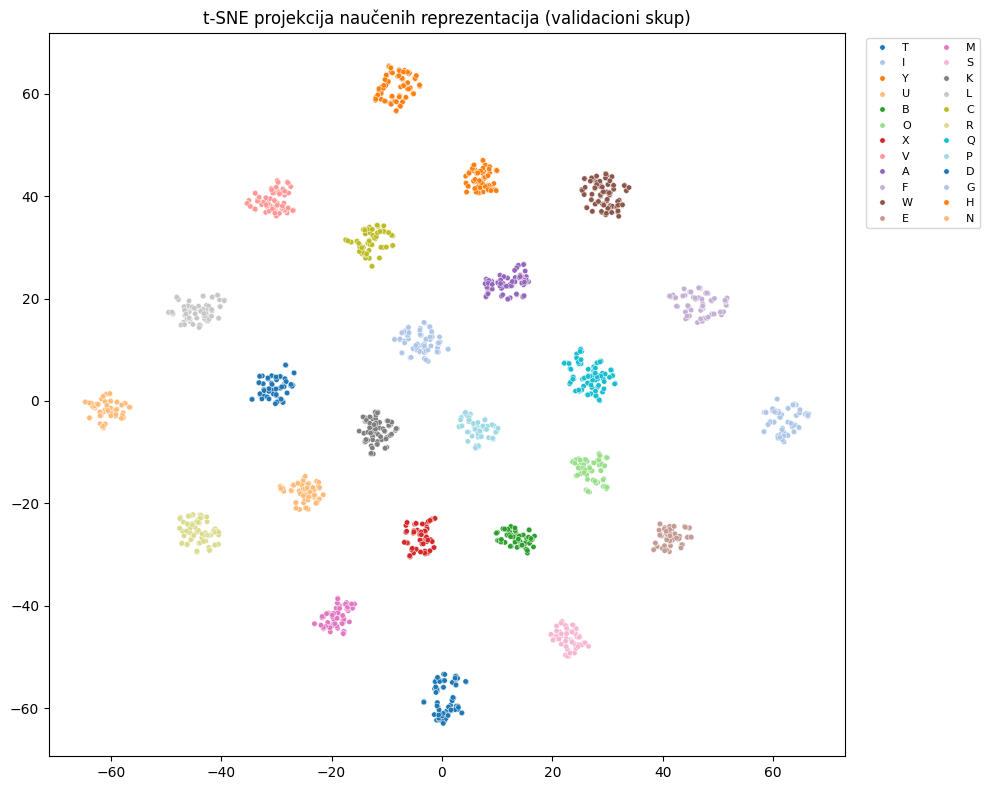

In [21]:
tsne_idx = rng.choice(len(val_embeddings), size=min(2000, len(val_embeddings)), replace=False)
tsne = TSNE(n_components=2, random_state=SEED, init="pca", perplexity=30)
embeddings_2d = tsne.fit_transform(val_embeddings[tsne_idx])

letters = [LABEL_TO_LETTER[l] for l in val_labels[tsne_idx]]

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=embeddings_2d[:, 0], y=embeddings_2d[:, 1],
    hue=letters, palette="tab20", s=15, legend="full",
)
plt.title("t-SNE projekcija naučenih reprezentacija (validacioni skup)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "triplet_embeddings_tsne.png", dpi=150)
plt.show()

## Čuvanje modela, embeddinga i rezultata

- embedding_net.pt - naučene težine mreže 
- embeddings.npz - već izračunati embeddinzi i labele za train/val/test
- triplet_summary.json - radi kasnijeg poređenja sa drugim modelom

In [22]:
model_path = RESULTS_DIR / "embedding_net.pt"
torch.save(model.state_dict(), model_path)
print(f"Model sačuvan: {model_path}")

embeddings_path = RESULTS_DIR / "embeddings.npz"
np.savez_compressed(
    embeddings_path,
    train_embeddings=train_embeddings, train_labels=train_labels,
    val_embeddings=val_embeddings, val_labels=val_labels,
    test_embeddings=test_embeddings, test_labels=test_labels,
)
print(f"Embeddinzi sačuvani: {embeddings_path}")

summary = {
    "model": "triplet_embedding_cnn_pytorch",
    "embedding_dim": EMBEDDING_DIM,
    "margin": MARGIN,
    "m_per_class": M_PER_CLASS,
    "triplet_batch_size": TRIPLET_BATCH_SIZE,
    "final_train_loss": float(history["train_loss"][-1]),
    "final_val_loss": float(history["val_loss"][-1]),
    "intra_class_distance": float(intra_class_dist),
    "inter_class_distance": float(inter_class_dist),
    "num_train_samples": len(train_ds),
    "num_val_samples": len(val_ds),
    "num_test_samples": len(test_ds),
    "epochs_ran": len(history["train_loss"]),
}
with open(RESULTS_DIR / "triplet_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

summary

Model sačuvan: ..\results\Triplet model\embedding_net.pt
Embeddinzi sačuvani: ..\results\Triplet model\embeddings.npz


{'model': 'triplet_embedding_cnn_pytorch',
 'embedding_dim': 128,
 'margin': 0.2,
 'm_per_class': 4,
 'triplet_batch_size': 96,
 'final_train_loss': 0.06863762293424872,
 'final_val_loss': 0.001664548580135618,
 'intra_class_distance': 0.24751290678977966,
 'inter_class_distance': 1.4208170175552368,
 'num_train_samples': 23336,
 'num_val_samples': 4119,
 'num_test_samples': 7172,
 'epochs_ran': 15}